In [6]:
# ============================================================
# FASE I – Proxecto II: Editor de Imaxes Intelixente
# Visión por Computador II – USC 2025-2026
# ============================================================
# Compatíbel con Google Colab e execución local

import os, sys, zipfile, subprocess, math, ssl, shutil
from pathlib import Path
from urllib.request import urlretrieve, urlopen

IN_COLAB = 'google.colab' in sys.modules
print('Entorno Colab:', IN_COLAB)


def pip_install(packages):
    cmd = [sys.executable, '-m', 'pip', 'install', '-q'] + packages
    subprocess.check_call(cmd)


try:
    import torch
except Exception:
    pip_install(['torch', 'torchvision'])

pip_install([
    'numpy', 'matplotlib', 'pillow', 'torchvision',
    'torchmetrics', 'diffusers', 'transformers',
    'accelerate', 'tqdm', 'scipy',
])


def is_valid_zip(path):
    """Comproba se o ficheiro existe e ten estrutura ZIP válida."""
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        return False
    if not zipfile.is_zipfile(path):
        return False
    try:
        with zipfile.ZipFile(path, 'r') as zf:
            _ = zf.namelist()  # forza lectura da táboa central
        return True
    except Exception:
        return False


def _download_urllib(url, output_path, verify_ssl=True):
    """Descarga con urllib; opcionalmente desactiva verificación SSL (último recurso)."""
    if verify_ssl:
        urlretrieve(url, output_path)
        return

    # Fallback manual para poder pasar contexto SSL
    ctx = ssl._create_unverified_context()
    with urlopen(url, context=ctx, timeout=120) as resp, open(output_path, 'wb') as f:
        f.write(resp.read())


def _download_curl(url, output_path, insecure=False):
    """Descarga con curl se está dispoñible no sistema."""
    if shutil.which('curl') is None:
        raise RuntimeError('curl non está instalado no sistema.')

    cmd = [
        'curl', '-L', '--fail', '--retry', '3', '--connect-timeout', '20',
        '--max-time', '0', '-o', str(output_path), url,
    ]
    if insecure:
        cmd.insert(1, '-k')
    subprocess.check_call(cmd)


def download_if_missing(urls, output_path, force=False):
    """
    Descarga robusta con varios métodos e valida ZIP ao final.
    `urls` pode ser unha URL (str) ou lista de URLs espello.
    """
    output_path = Path(output_path)
    if isinstance(urls, str):
        urls = [urls]

    if output_path.exists() and not force:
        if is_valid_zip(output_path):
            print(f'Xa existe e é válido: {output_path}')
            return output_path
        print(f'Arquivo existente corrupto/non ZIP, elimínase: {output_path}')
        output_path.unlink(missing_ok=True)

    last_error = None
    for url in urls:
        print(f'Intentando descarga: {url}')

        # 1) urllib con verificación SSL
        try:
            output_path.unlink(missing_ok=True)
            _download_urllib(url, output_path, verify_ssl=True)
            if is_valid_zip(output_path):
                print(f'Descarga completada e validada (urllib SSL): {output_path}')
                return output_path
            raise RuntimeError('Descargado pero non é ZIP válido')
        except Exception as e:
            last_error = f'urllib SSL ({url}): {e}'
            print('  fallo ->', last_error)

        # 2) curl con SSL normal
        try:
            output_path.unlink(missing_ok=True)
            _download_curl(url, output_path, insecure=False)
            if is_valid_zip(output_path):
                print(f'Descarga completada e validada (curl SSL): {output_path}')
                return output_path
            raise RuntimeError('Descargado pero non é ZIP válido')
        except Exception as e:
            last_error = f'curl SSL ({url}): {e}'
            print('  fallo ->', last_error)

        # 3) último recurso: sen verificación SSL
        try:
            output_path.unlink(missing_ok=True)
            _download_urllib(url, output_path, verify_ssl=False)
            if is_valid_zip(output_path):
                print(f'Descarga completada e validada (urllib sen SSL): {output_path}')
                return output_path
            raise RuntimeError('Descargado pero non é ZIP válido')
        except Exception as e:
            last_error = f'urllib sen SSL ({url}): {e}'
            print('  fallo ->', last_error)

        # 4) último recurso alternativo: curl -k
        try:
            output_path.unlink(missing_ok=True)
            _download_curl(url, output_path, insecure=True)
            if is_valid_zip(output_path):
                print(f'Descarga completada e validada (curl -k): {output_path}')
                return output_path
            raise RuntimeError('Descargado pero non é ZIP válido')
        except Exception as e:
            last_error = f'curl -k ({url}): {e}'
            print('  fallo ->', last_error)

    output_path.unlink(missing_ok=True)
    raise RuntimeError(
        'Non foi posible descargar un ZIP válido. Último erro: ' + str(last_error)
    )


def unzip_if_needed(zip_path, target_hint):
    zip_path = Path(zip_path)
    target_hint = Path(target_hint)
    if target_hint.exists():
        print(f'Xa descomprimido: {target_hint}')
        return

    if not is_valid_zip(zip_path):
        raise RuntimeError(f'ZIP inválido antes de descomprimir: {zip_path}')

    print(f'Descomprimiendo: {zip_path}')
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall('.')


# Espellos: probamos HTTPS e HTTP para contornas con proxies/certificados problemáticos
VAL_URLS = [
    'https://images.cocodataset.org/zips/val2017.zip',
    'http://images.cocodataset.org/zips/val2017.zip',
]
ANN_URLS = [
    'https://images.cocodataset.org/annotations/annotations_trainval2017.zip',
    'http://images.cocodataset.org/annotations/annotations_trainval2017.zip',
]

val_zip = download_if_missing(VAL_URLS, 'val2017.zip')
ann_zip = download_if_missing(ANN_URLS, 'annotations_trainval2017.zip')

unzip_if_needed(val_zip, 'val2017')
unzip_if_needed(ann_zip, 'annotations')
print('Dataset COCO listo para usar.')


Entorno Colab: True
Xa existe e é válido: val2017.zip
Xa existe e é válido: annotations_trainval2017.zip
Xa descomprimido: val2017
Xa descomprimido: annotations
Dataset COCO listo para usar.


## Configuración global e directorios de resultados

Todos os parámetros axustábeis da Fase I están nun único lugar para facilitar a reprodución dos experimentos.


In [7]:
import json, math, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm
from PIL import Image

# ── Supercategoría escollida do COCO ─────────────────────────────────────────
# Opciones dispoñibles: 'animal', 'vehicle', 'furniture', 'food', 'outdoor', ...
SUPERCATEGORIA = 'vehicle'   # ← CAMBIA a outra supercategoría se queres probar con outra
print('Supercategoría escollida:', SUPERCATEGORIA)

# ── Modo de execución ────────────────────────────────────────────────────────
# 'smoke'  → proba rápida (poucos epochs, menos imaxes)  – ideal para validar pipeline
# 'full'   → adestramento de entrega
RUN_MODE = 'full'   # ← CAMBIA a 'full' para a entrega definitiva

if RUN_MODE == 'smoke':
    BATCH_SIZE       = 32
    LR               = 2e-4
    TIMESTEPS        = 100
    MAX_TRAIN_IMAGES = 400
    EPOCHS_BASE      = 2
    EPOCHS_MEJORA    = 2
elif RUN_MODE == 'full':
    BATCH_SIZE       = 64
    LR               = 2e-4
    TIMESTEPS        = 300
    MAX_TRAIN_IMAGES = 1200
    EPOCHS_BASE      = 15
    EPOCHS_MEJORA    = 15
else:
    raise ValueError("RUN_MODE debe ser 'smoke' ou 'full'")

# ── Rutas ────────────────────────────────────────────────────────────────────
IN_COLAB = 'google.colab' in __import__('sys').modules
ROOT     = Path('/content') if IN_COLAB else Path('.').resolve()
OUT      = ROOT / 'practica_2' / 'resultados'
OUT.mkdir(parents=True, exist_ok=True)

RUTAS = {
    'reales_fase1'    : ROOT / 'dataset_fase1',
    'generadas_fase1' : OUT  / 'fase1_generadas',
    'denoising_fase1' : OUT  / 'fase1_denoising',
    'metricas'        : OUT  / 'metricas',
}
for p in RUTAS.values():
    p.mkdir(parents=True, exist_ok=True)

CHECKLIST = {
    'fase1_dominio'       : False,
    'fase1_grid_16v16'    : False,
    'fase1_denoising'     : False,
    'fase1_fid'           : False,
}

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print('Device       :', DEVICE)
print('Supercategoría:', SUPERCATEGORIA)
print('RUN_MODE     :', RUN_MODE)
print('BATCH_SIZE   :', BATCH_SIZE)
print('TIMESTEPS    :', TIMESTEPS)
print('MAX_TRAIN    :', MAX_TRAIN_IMAGES)
print('Directorio   :', OUT)


Supercategoría escollida: vehicle
Device       : cuda
Supercategoría: vehicle
RUN_MODE     : full
BATCH_SIZE   : 64
TIMESTEPS    : 300
MAX_TRAIN    : 1200
Directorio   : /content/practica_2/resultados


## Fase I – Paso 1: Selección do dominio e preprocesado a 64×64

Extraemos as imaxes da supercategoría escollida do dataset COCO e gardámolas redimensionadas a **64×64** píxeles.


Categorías en "vehicle": 8 → ['bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat']
Imaxes dispoñibles (filtradas): 1160 | Usando: 1160
Cartafol anterior eliminado: /content/dataset_fase1
Imaxes 64×64 gardadas en: /content/dataset_fase1 (1160 imaxes)

Checklist fase1_dominio = True


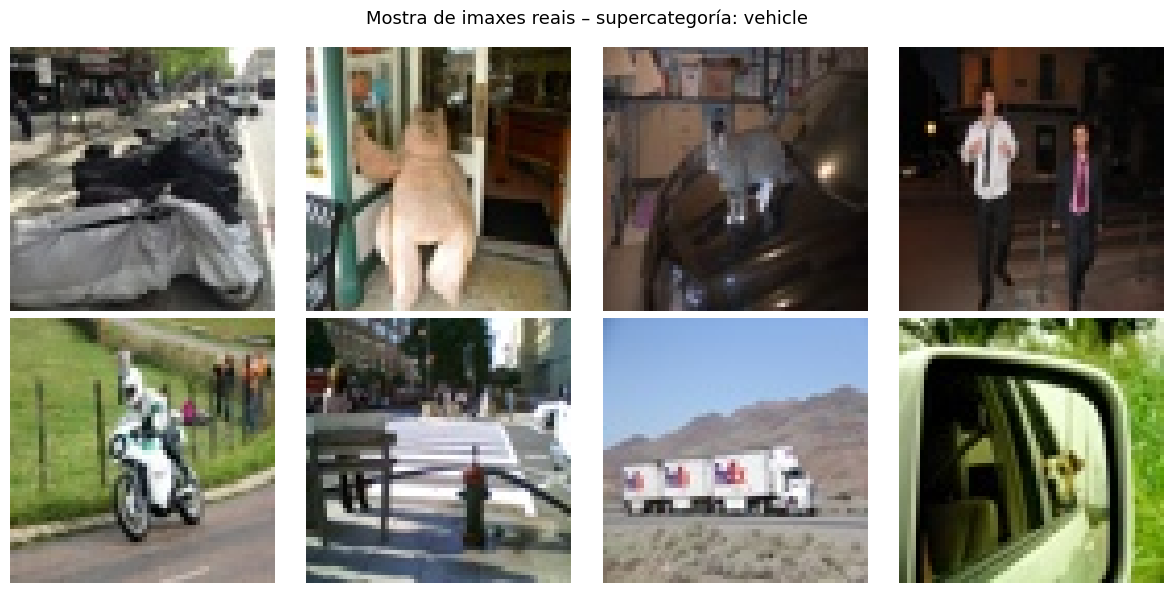

In [8]:
import shutil

ANN_INSTANCES = Path('annotations') / 'instances_val2017.json'
SOURCE_DIR    = Path('val2017')
OUTPUT_DIR    = RUTAS['reales_fase1']
IMG_SIZE      = (64, 64)


def seleccionar_dominio(supercategoria=SUPERCATEGORIA, max_images=MAX_TRAIN_IMAGES):
    """Extrae IDs de imaxes da supercategoría, limpa o cartafol destino e copia a 64x64."""
    with open(ANN_INSTANCES, 'r') as f:
        data = json.load(f)

    # Categorías da supercategoría escollida
    cat_ids = {c['id'] for c in data['categories']
               if c['supercategory'] == supercategoria}
    print(f'Categorías en "{supercategoria}": {len(cat_ids)} → {[c["name"] for c in data["categories"] if c["supercategory"] == supercategoria]}')

    # IDs das imaxes que conteñen POLO MENOS UN obxecto desa supercategoría
    image_ids = {a['image_id'] for a in data['annotations']
                 if a['category_id'] in cat_ids}

    # Nomes de ficheiro correspondentes
    filenames = [img['file_name'] for img in data['images']
                 if img['id'] in image_ids]

    random.seed(42)
    random.shuffle(filenames)
    seleccion = filenames[:max_images]
    print(f'Imaxes dispoñibles (filtradas): {len(filenames)} | Usando: {len(seleccion)}')

    # ── IMPORTANTE: limpar o cartafol destino para evitar mestura de dominios ──
    if OUTPUT_DIR.exists():
        shutil.rmtree(OUTPUT_DIR)
        print(f'Cartafol anterior eliminado: {OUTPUT_DIR}')
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # Redimensionar a 64×64 e gardar
    procesadas = 0
    nomes_gardados = []
    for fname in seleccion:
        src = SOURCE_DIR / fname
        dst = OUTPUT_DIR / fname
        if not src.exists():
            continue
        img = Image.open(src).convert('RGB').resize(IMG_SIZE, Image.BICUBIC)
        img.save(dst, quality=95)
        procesadas += 1
        nomes_gardados.append(fname)

    print(f'Imaxes 64×64 gardadas en: {OUTPUT_DIR} ({procesadas} imaxes)')
    return procesadas, nomes_gardados


n_imgs, nomes = seleccionar_dominio()
CHECKLIST['fase1_dominio'] = n_imgs > 0
print('\nChecklist fase1_dominio =', CHECKLIST['fase1_dominio'])

# Vista rápida: mostramos exactamente as 8 primeiras imaxes do run actual
archivos = [OUTPUT_DIR / n for n in nomes[:8] if (OUTPUT_DIR / n).exists()]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax in axes.flat:
    ax.axis('off')
for ax, p in zip(axes.flat, archivos):
    ax.imshow(np.array(Image.open(p)))
    ax.axis('off')
fig.suptitle(f'Mostra de imaxes reais – supercategoría: {SUPERCATEGORIA}', fontsize=13)
plt.tight_layout()
plt.savefig(OUT / 'fase1_muestra_reales.png', dpi=150, bbox_inches='tight')
plt.show()


## Fase I – Paso 2: Arquitectura do modelo de difusión (DDPM)

Implementamos un **DDPM lixeiro** baseado en U-Net con:
- **ResBlocks** con embedding de timestep sinusoidal.
- **Self-Attention** opcional (actívase con `use_attn=True`).
- Scheduler **lineal** ou **coseno** (configurable por experimento).


In [9]:
# ─── Funcions de scheduler e difusión cara adiante ───────────────────────────

def linear_beta_schedule(timesteps, beta_start=0.0001, beta_end=0.02):
    beta_t    = torch.linspace(beta_start, beta_end, timesteps)
    alpha_t   = 1.0 - beta_t
    alpha_bar = torch.cumprod(alpha_t, dim=0)
    return beta_t, alpha_t, alpha_bar


def cosine_beta_schedule(timesteps, s=0.008):
    """Scheduler coseno (Nichol & Dhariwal, 2021)."""
    t         = torch.linspace(0, timesteps, timesteps + 1)
    f         = torch.cos(((t / timesteps + s) / (1 + s)) * math.pi * 0.5) ** 2
    alpha_bar = f / f[0]
    betas     = 1 - (alpha_bar[1:] / alpha_bar[:-1])
    betas     = torch.clamp(betas, 1e-5, 0.999)
    alphas    = 1.0 - betas
    return betas, alphas, alpha_bar[1:]


def forward_diffusion(x0, t, alpha_bar_t):
    """Proceso de difusión cara adiante: q(x_t | x_0)."""
    alpha_bar = alpha_bar_t[t].view(-1, 1, 1, 1).to(x0.device)
    epsilon   = torch.randn_like(x0)
    x_t       = torch.sqrt(alpha_bar) * x0 + torch.sqrt(1 - alpha_bar) * epsilon
    return x_t, epsilon


def sample_timesteps(batch_size, timesteps):
    return torch.randint(0, timesteps, (batch_size,))


# ─── Embedding de timestep (sinusoidal) ──────────────────────────────────────

def timestep_embedding(t, dim):
    half  = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(half, device=t.device) / max(half - 1, 1)
    )
    x   = t[:, None].float() * freqs[None, :]
    emb = torch.cat([torch.sin(x), torch.cos(x)], dim=-1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb


# ─── Bloque residual con atención opcional ───────────────────────────────────

class ResBlock(nn.Module):
    """Bloque residual con condicionamento por timestep e Self-Attention opcional.
    
    NOTA: só activar use_attn en resolucións baixas (≤16×16) para evitar OOM.
    A secuencia de atención ten tamaño H*W; en 64×64 serían 4096 tokens por imaxe.
    """

    def __init__(self, in_ch, out_ch, t_dim, use_attn=False):
        super().__init__()
        self.norm1  = nn.GroupNorm(min(8, in_ch), in_ch)
        self.conv1  = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2  = nn.GroupNorm(min(8, out_ch), out_ch)
        self.conv2  = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.t_proj = nn.Linear(t_dim, out_ch)
        self.skip   = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.use_attn = use_attn
        if use_attn:
            self.attn_norm = nn.GroupNorm(min(8, out_ch), out_ch)
            self.attn      = nn.MultiheadAttention(out_ch, num_heads=4, batch_first=True)

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.t_proj(F.silu(t_emb))[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        h = h + self.skip(x)

        if self.use_attn:
            b, c, hh, ww = h.shape
            seq  = self.attn_norm(h).flatten(2).transpose(1, 2)   # (B, H*W, C)
            seq, _ = self.attn(seq, seq, seq, need_weights=False)
            h = h + seq.transpose(1, 2).reshape(b, c, hh, ww)

        return h


# ─── U-Net lixeira (encoder → bottleneck → decoder) ─────────────────────────

class TinyUNet(nn.Module):
    """
    U-Net lixeira para DDPM en 64×64.

    Resolucións por etapa:
      Encoder:      64×64 → 32×32 → 16×16
      Bottleneck:   16×16  (Self-Attention activa aquí, secuencia de só 256 tokens)
      Decoder:      16×16 → 32×32 → 64×64  (skip connections)

    A Self-Attention NUNCA se aplica en 64×64 (4096 tokens) nin 32×32 (1024 tokens)
    porque dispararía o consumo de memoria en O(N²).
    Cando use_attn=True, actívase unicamente no bottleneck (16×16 = 256 tokens).
    """

    def __init__(self, base=64, t_dim=256, use_attn=False):
        super().__init__()
        self.t_mlp = nn.Sequential(
            nn.Linear(t_dim, t_dim * 2), nn.SiLU(), nn.Linear(t_dim * 2, t_dim)
        )

        # Encoder — SEN atención (64×64 e 32×32 son demasiado grandes)
        self.in_conv = nn.Conv2d(3, base, 3, padding=1)
        self.down1   = ResBlock(base,     base * 2, t_dim, use_attn=False)
        self.pool1   = nn.AvgPool2d(2)   # 64→32
        self.down2   = ResBlock(base * 2, base * 4, t_dim, use_attn=False)
        self.pool2   = nn.AvgPool2d(2)   # 32→16

        # Bottleneck — atención ACTIVADA só se use_attn=True (16×16 = 256 tokens: OK)
        self.mid1 = ResBlock(base * 4, base * 4, t_dim, use_attn=use_attn)
        self.mid2 = ResBlock(base * 4, base * 4, t_dim, use_attn=use_attn)

        # Decoder — SEN atención
        self.up2      = nn.Upsample(scale_factor=2, mode='nearest')  # 16→32
        self.upblock2 = ResBlock(base * 4 + base * 4, base * 2, t_dim, use_attn=False)
        self.up1      = nn.Upsample(scale_factor=2, mode='nearest')  # 32→64
        self.upblock1 = ResBlock(base * 2 + base * 2, base,     t_dim, use_attn=False)

        self.out_norm = nn.GroupNorm(min(8, base), base)
        self.out_conv = nn.Conv2d(base, 3, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.t_mlp(timestep_embedding(t, 256))

        # Encoder
        x0  = self.in_conv(x)           # (B, base,   64, 64)
        d1  = self.down1(x0, t_emb)     # (B, base*2, 64, 64)
        d1p = self.pool1(d1)            # (B, base*2, 32, 32)
        d2  = self.down2(d1p, t_emb)    # (B, base*4, 32, 32)
        d2p = self.pool2(d2)            # (B, base*4, 16, 16)

        # Bottleneck (atención só aquí)
        m = self.mid1(d2p, t_emb)
        m = self.mid2(m,   t_emb)       # (B, base*4, 16, 16)

        # Decoder con skip connections
        u2 = self.up2(m)                                              # (B, base*4, 32, 32)
        u2 = self.upblock2(torch.cat([u2, d2], dim=1), t_emb)        # (B, base*2, 32, 32)
        u1 = self.up1(u2)                                             # (B, base*2, 64, 64)
        u1 = self.upblock1(torch.cat([u1, d1], dim=1), t_emb)        # (B, base,   64, 64)

        return self.out_conv(F.silu(self.out_norm(u1)))


# ─── Clase DDPM (q_sample + p_sample) ───────────────────────────────────────

class DDPM:
    """Encapsula o scheduler de ruido e o mostreo reverso."""

    def __init__(self, timesteps=200, schedule='linear'):
        self.timesteps = timesteps
        if schedule == 'cosine':
            betas, alphas, alpha_bar = cosine_beta_schedule(timesteps)
        else:
            betas, alphas, alpha_bar = linear_beta_schedule(timesteps)

        alpha_bar_prev = torch.cat([torch.ones(1), alpha_bar[:-1]], dim=0)
        posterior_var = betas * (1 - alpha_bar_prev) / (1 - alpha_bar)
        posterior_var = torch.clamp(posterior_var, min=1e-20)

        self.betas              = betas.to(DEVICE)
        self.alphas             = alphas.to(DEVICE)
        self.alpha_bar          = alpha_bar.to(DEVICE)
        self.alpha_bar_prev     = alpha_bar_prev.to(DEVICE)
        self.posterior_variance = posterior_var.to(DEVICE)

    def q_sample(self, x0, t):
        """Proceso cara adiante: engade ruido a x0 no paso t."""
        return forward_diffusion(x0, t, self.alpha_bar)

    @torch.no_grad()
    def p_sample(self, model, x, t_idx):
        """Un paso de denoising reverso: p(x_{t-1} | x_t)."""
        b = x.size(0)
        t_batch = torch.full((b,), t_idx, device=x.device, dtype=torch.long)
        eps_theta = model(x, t_batch)

        alpha_t       = self.alphas[t_idx]
        a_bar_t       = self.alpha_bar[t_idx]
        a_bar_prev_t  = self.alpha_bar_prev[t_idx]
        beta_t        = self.betas[t_idx]

        # Predición de x0 para estabilizar a media posterior
        x0_pred = (x - torch.sqrt(1 - a_bar_t) * eps_theta) / torch.sqrt(a_bar_t)
        x0_pred = x0_pred.clamp(-1, 1)

        coef_x0 = (torch.sqrt(a_bar_prev_t) * beta_t) / (1 - a_bar_t)
        coef_xt = (torch.sqrt(alpha_t) * (1 - a_bar_prev_t)) / (1 - a_bar_t)
        mean = coef_x0 * x0_pred + coef_xt * x

        if t_idx > 0:
            noise = torch.randn_like(x)
            return mean + torch.sqrt(self.posterior_variance[t_idx]) * noise
        return mean


n_params = sum(p.numel() for p in TinyUNet(base=64, use_attn=True).parameters())
print(f'TinyUNet (base=64, attn=True) → {n_params:,} parámetros')
print('Atención activada UNICAMENTE no bottleneck 16×16 (256 tokens) — sen risco de OOM.')

TinyUNet (base=64, attn=True) → 5,591,107 parámetros
Atención activada UNICAMENTE no bottleneck 16×16 (256 tokens) — sen risco de OOM.


## Fase I – Paso 3: Dataset e Data Augmentation

Definimos o `Dataset` e o `DataLoader` con opción de augmentation (flip horizontal + jitter de cor).


In [10]:
def get_transform(use_aug=False):
    """Transformacións de entrada. Con use_aug=True engade Data Augmentation."""
    ops = []
    if use_aug:
        ops += [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.05),
            transforms.RandomGrayscale(p=0.05),
        ]
    ops += [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
    return transforms.Compose(ops)


class FolderImageDataset(Dataset):
    """Dataset sinxelo que carga imaxes dun cartafol."""

    def __init__(self, folder, transform=None, max_items=None):
        self.folder    = Path(folder)
        self.transform = transform
        exts  = {'.jpg', '.jpeg', '.png'}
        paths = sorted([p for p in self.folder.iterdir()
                        if p.suffix.lower() in exts]) if self.folder.exists() else []
        self.paths = paths[:max_items] if max_items is not None else paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, 0


def get_loader(batch_size=64, use_aug=False, max_items=None):
    ds = FolderImageDataset(
        RUTAS['reales_fase1'],
        transform=get_transform(use_aug=use_aug),
        max_items=max_items,
    )
    if len(ds) == 0:
        raise RuntimeError('dataset_fase1 está baleiro. Executa o bloque de preprocesado primeiro.')
    nw = min(2, os.cpu_count() or 1)
    print(f'Imaxes de adestramento: {len(ds)} | Augmentation: {use_aug}')
    return DataLoader(ds, batch_size=batch_size, shuffle=True,
                      num_workers=nw, pin_memory=(DEVICE == 'cuda'))

import os
# Test rápido
_ = get_loader(batch_size=BATCH_SIZE, use_aug=True, max_items=MAX_TRAIN_IMAGES)
print('DataLoader OK')


Imaxes de adestramento: 1160 | Augmentation: True
DataLoader OK


## Fase I – Paso 4: Mostreo e visualización do proceso de denoising

A función `sample_images` xera imaxes sintéticas e garda instantáneas do proceso iterativo de denoising.


In [11]:
@torch.no_grad()
def sample_images(model, ddpm, n=16, save_dir=None, save_denoising_dir=None,
                  seed=1234, gen_batch_size=16):
    """
    Xera `n` imaxes desde ruido puro usando mostreo DDPM reverso.
    
    Parámetro gen_batch_size: cantas imaxes procesar á vez durante o mostreo.
    Redúceo se aparece OOM (por defecto 16, seguro para GPUs de ~15 GB con base=64).
    """
    model.eval()
    all_imgs = []
    denoise_snapshots = []
    T = ddpm.timesteps
    snapshot_steps = {T - 1, int(T * 0.66), int(T * 0.33), 0}
    first_batch = True

    g = torch.Generator(device=DEVICE).manual_seed(seed)

    # Procesar en mini-lotes para evitar OOM
    for batch_start in range(0, n, gen_batch_size):
        batch_n = min(gen_batch_size, n - batch_start)
        x = torch.randn((batch_n, 3, 64, 64), device=DEVICE, generator=g)

        for t in reversed(range(T)):
            x = ddpm.p_sample(model, x, t)
            # Gardar snapshots só do primeiro mini-lote
            if first_batch and save_denoising_dir is not None and t in snapshot_steps:
                denoise_snapshots.append((t, x[0:1].detach().cpu().clone()))

        all_imgs.append(x.clamp(-1, 1).detach().cpu())
        first_batch = False

    imgs_tensor = torch.cat(all_imgs, dim=0)          # (n, 3, 64, 64)
    imgs_np = ((imgs_tensor + 1) / 2 * 255).byte().permute(0, 2, 3, 1).numpy()

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        for i in range(len(imgs_np)):
            Image.fromarray(imgs_np[i]).save(save_dir / f'gen_{i:03d}.png')

    if save_denoising_dir is not None:
        save_denoising_dir = Path(save_denoising_dir)
        save_denoising_dir.mkdir(parents=True, exist_ok=True)
        for t_val, snap in denoise_snapshots:
            arr = (snap[0].clamp(-1, 1) + 1) / 2
            arr = (arr * 255).byte().permute(1, 2, 0).numpy()
            Image.fromarray(arr).save(save_denoising_dir / f'step_{t_val:04d}.png')

    return imgs_np


print('Función sample_images definida correctamente.')
print('Mostreo en mini-lotes (gen_batch_size=16) — seguro para GPUs de ~15 GB.')


Función sample_images definida correctamente.
Mostreo en mini-lotes (gen_batch_size=16) — seguro para GPUs de ~15 GB.


## Fase I – Paso 5: Loop de adestramento

A función `train_ddpm` acepta un dicionario de configuración que inclúe:
- `use_aug`: activar Data Augmentation
- `use_attn`: incluír capas de Self-Attention na U-Net  
- `schedule`: `'linear'` ou `'cosine'`
- `epochs`: número de épocas


In [12]:
import time
import copy


def _build_ema_model(model):
    ema_model = copy.deepcopy(model).to(DEVICE)
    ema_model.eval()
    for p in ema_model.parameters():
        p.requires_grad_(False)
    return ema_model


@torch.no_grad()
def _ema_update(ema_model, model, decay):
    ema_params = dict(ema_model.named_parameters())
    for name, p in model.named_parameters():
        ema_params[name].mul_(decay).add_(p.data, alpha=1.0 - decay)


def train_ddpm(cfg):
    """Adestra un DDPM coa configuración cfg e devolve resultados para comparación."""
    loader = get_loader(
        batch_size=BATCH_SIZE,
        use_aug=cfg.get('use_aug', False),
        max_items=MAX_TRAIN_IMAGES,
    )

    base_ch = cfg.get('base', 64)
    timesteps_cfg = cfg.get('timesteps', TIMESTEPS)
    grad_accum = max(1, int(cfg.get('grad_accum', 1)))
    use_amp = bool(cfg.get('use_amp', DEVICE == 'cuda')) and DEVICE == 'cuda'
    use_ema = bool(cfg.get('use_ema', False))
    ema_decay = float(cfg.get('ema_decay', 0.999))
    noise_offset = float(cfg.get('noise_offset', 0.0))

    model = TinyUNet(base=base_ch, use_attn=cfg.get('use_attn', False)).to(DEVICE)
    ddpm = DDPM(timesteps=timesteps_cfg, schedule=cfg.get('schedule', 'linear'))
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg['epochs'])

    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    ema_model = _build_ema_model(model) if use_ema else None

    history = []
    start_time = time.time()

    for epoch in range(cfg['epochs']):
        model.train()
        pbar = tqdm(loader, desc=f"{cfg['nome']} | epoch {epoch+1}/{cfg['epochs']}")
        running = 0.0
        count = 0

        opt.zero_grad(set_to_none=True)
        for step, (x, _) in enumerate(pbar):
            x = x.to(DEVICE)
            b = x.size(0)

            t = sample_timesteps(b, ddpm.timesteps).to(DEVICE)

            if noise_offset > 0:
                base_noise = torch.randn_like(x)
                extra = noise_offset * torch.randn((b, x.shape[1], 1, 1), device=DEVICE)
                noise = base_noise + extra
                a_bar = ddpm.alpha_bar[t].view(-1, 1, 1, 1)
                x_t = torch.sqrt(a_bar) * x + torch.sqrt(1 - a_bar) * noise
            else:
                x_t, noise = ddpm.q_sample(x, t)

            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp):
                pred = model(x_t, t)
                loss = F.mse_loss(pred, noise) / grad_accum

            scaler.scale(loss).backward()

            if (step + 1) % grad_accum == 0:
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(opt)
                scaler.update()
                opt.zero_grad(set_to_none=True)

                if use_ema:
                    _ema_update(ema_model, model, ema_decay)

            running += (loss.item() * grad_accum) * b
            count += b
            pbar.set_postfix(loss=f"{(loss.item() * grad_accum):.4f}")

        if len(loader) % grad_accum != 0:
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
            opt.zero_grad(set_to_none=True)
            if use_ema:
                _ema_update(ema_model, model, ema_decay)

        sched.step()
        epoch_loss = running / max(count, 1)
        history.append(epoch_loss)
        print(f"[{cfg['nome']}] epoch={epoch+1}/{cfg['epochs']}  loss={epoch_loss:.5f}")

    elapsed = time.time() - start_time
    model_eval = ema_model if use_ema else model

    info = {
        'loss_final': history[-1],
        'seconds': elapsed,
        'base': base_ch,
        'timesteps': timesteps_cfg,
        'use_ema': use_ema,
        'use_amp': use_amp,
        'grad_accum': grad_accum,
        'noise_offset': noise_offset,
    }

    return model_eval, ddpm, history, info


def save_loss_plot(histories, out_file):
    """Garda a gráfica comparativa de curvas de adestramento."""
    plt.figure(figsize=(10, 4.5))
    for name, hist in histories.items():
        plt.plot(hist, marker='o', label=name)
    plt.xlabel('Época')
    plt.ylabel('MSE (ruido estimado)')
    plt.title('Fase I – Curvas de adestramento DDPM (ablation)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_file, dpi=180, bbox_inches='tight')
    plt.show()
    print('Gardado:', out_file)


print('Funcions de adestramento avanzadas definidas.')

Funcions de adestramento avanzadas definidas.


## Fase I – Paso 6: Experimentación e melloras

Comparamos configuracións base e avanzadas para analizar o impacto no rendemento.

Melloras aplicadas:

1. **Data Augmentation** no dataset de adestramento.
2. **Self-Attention** na U-Net (bottleneck).
3. **Scheduler de ruido** (`linear` vs `cosine`).
4. **EMA de pesos** (Exponential Moving Average) para estabilizar a xeración.
5. **Mixed Precision (AMP)** para mellorar estabilidade/velocidade en GPU.
6. **Gradient Accumulation** para aumentar batch efectivo sen OOM.
7. **Noise offset** no ruído de adestramento para mellorar cobertura do espazo xerativo.
8. **Máis capacidade de modelo** (`base` maior) no run final.

O último experimento (`all_mejoras_final`) executa todas as melloras xuntas e úsase para a avaliación final de Fase I.


Experimento: baseline_linear
Imaxes de adestramento: 1160 | Augmentation: False


/tmp/ipykernel_1157/2787059727.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


baseline_linear | epoch 1/15:   0%|          | 0/19 [00:00<?, ?it/s]

[baseline_linear] epoch=1/15  loss=0.62500


baseline_linear | epoch 2/15:   0%|          | 0/19 [00:00<?, ?it/s]

...

[all_mejoras_final] epoch=18/20  loss=0.08824


all_mejoras_final | epoch 19/20:   0%|          | 0/19 [00:00<?, ?it/s]

[all_mejoras_final] epoch=19/20  loss=0.09376


all_mejoras_final | epoch 20/20:   0%|          | 0/19 [00:00<?, ?it/s]

[all_mejoras_final] epoch=20/20  loss=0.08869


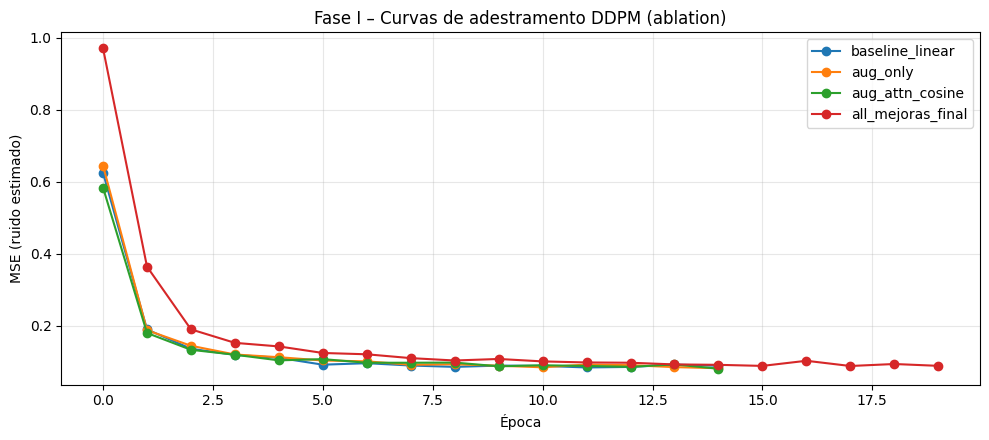

Gardado: /content/practica_2/resultados/fase1_training_losses_ablation.png

Resumo de experimentos (ablation):
- baseline_linear    | loss=0.08889 |   99.6s | aug=False attn=False sched=linear ema=False amp=False acc=1 base=64 T=300
- aug_only           | loss=0.08207 |  118.1s | aug=True attn=False sched=linear ema=False amp=False acc=1 base=64 T=300
- aug_attn_cosine    | loss=0.08072 |   96.0s | aug=True attn=True sched=cosine ema=False amp=True acc=1 base=64 T=300
- all_mejoras_final  | loss=0.08869 |  184.1s | aug=True attn=True sched=cosine ema=True amp=True acc=2 base=80 T=300

Mellor por loss: aug_attn_cosine | loss final: 0.08072

Run final seleccionado para avaliación: all_mejoras_final | loss=0.08869
Este modelo usarase nas seguintes celdas para xeración, grid e FID.


In [13]:
EXPERIMENTOS_FASE1 = [
    {
        'nome': 'baseline_linear',
        'use_aug': False,
        'use_attn': False,
        'schedule': 'linear',
        'epochs': EPOCHS_BASE,
        'base': 64,
        'timesteps': TIMESTEPS,
        'use_ema': False,
        'use_amp': False,
        'grad_accum': 1,
        'noise_offset': 0.0,
    },
    {
        'nome': 'aug_only',
        'use_aug': True,
        'use_attn': False,
        'schedule': 'linear',
        'epochs': EPOCHS_BASE,
        'base': 64,
        'timesteps': TIMESTEPS,
        'use_ema': False,
        'use_amp': False,
        'grad_accum': 1,
        'noise_offset': 0.0,
    },
    {
        'nome': 'aug_attn_cosine',
        'use_aug': True,
        'use_attn': True,
        'schedule': 'cosine',
        'epochs': EPOCHS_MEJORA,
        'base': 64,
        'timesteps': TIMESTEPS,
        'use_ema': False,
        'use_amp': True,
        'grad_accum': 1,
        'noise_offset': 0.0,
    },
    {
        'nome': 'all_mejoras_final',
        'use_aug': True,
        'use_attn': True,
        'schedule': 'cosine',
        'epochs': EPOCHS_MEJORA + (5 if RUN_MODE == 'full' else 0),
        'base': 80 if RUN_MODE == 'full' else 64,
        'timesteps': TIMESTEPS,
        'use_ema': True,
        'ema_decay': 0.999,
        'use_amp': True,
        'grad_accum': 2 if RUN_MODE == 'full' else 1,
        'noise_offset': 0.01,
    },
]

resultados_fase1 = {}
loss_histories = {}
resumen_rows = []

for cfg in EXPERIMENTOS_FASE1:
    print('\n' + '=' * 70)
    print(f"Experimento: {cfg['nome']}")
    model_eval, ddpm, hist, info = train_ddpm(cfg)

    resultados_fase1[cfg['nome']] = {
        'model': model_eval,
        'ddpm': ddpm,
        'loss': hist[-1],
        'cfg': cfg,
        'info': info,
    }
    loss_histories[cfg['nome']] = hist

    resumen_rows.append({
        'experimento': cfg['nome'],
        'loss_final': round(info['loss_final'], 5),
        'segundos': round(info['seconds'], 1),
        'aug': cfg.get('use_aug', False),
        'attn': cfg.get('use_attn', False),
        'sched': cfg.get('schedule', 'linear'),
        'ema': info['use_ema'],
        'amp': info['use_amp'],
        'grad_accum': info['grad_accum'],
        'noise_offset': info['noise_offset'],
        'base': info['base'],
        'timesteps': info['timesteps'],
    })

save_loss_plot(loss_histories, OUT / 'fase1_training_losses_ablation.png')

# Escoller o mellor por loss para referencia
best_name = min(resultados_fase1, key=lambda k: resultados_fase1[k]['loss'])
best_loss = resultados_fase1[best_name]['loss']

print('\n' + '=' * 70)
print('Resumo de experimentos (ablation):')
for r in resumen_rows:
    print(
        f"- {r['experimento']:18s} | loss={r['loss_final']:.5f} | "
        f"{r['segundos']:6.1f}s | aug={r['aug']} attn={r['attn']} "
        f"sched={r['sched']} ema={r['ema']} amp={r['amp']} "
        f"acc={r['grad_accum']} base={r['base']} T={r['timesteps']}"
    )

print(f"\nMellor por loss: {best_name} | loss final: {best_loss:.5f}")

# Último run para avaliación final: todas as melloras
FINAL_RUN_NAME = 'all_mejoras_final'
if FINAL_RUN_NAME in resultados_fase1:
    best_name = FINAL_RUN_NAME
    best_loss = resultados_fase1[best_name]['loss']

best_model = resultados_fase1[best_name]['model']
best_ddpm = resultados_fase1[best_name]['ddpm']

print(f"\nRun final seleccionado para avaliación: {best_name} | loss={best_loss:.5f}")
print('Este modelo usarase nas seguintes celdas para xeración, grid e FID.')

## Fase I – Paso 7: Xeración de imaxes sintéticas e proceso de denoising

Co mellor modelo xeramos **64 imaxes sintéticas** e gardamos os snapshots do proceso de denoising.


In [14]:
if 'best_name' not in globals() or 'best_model' not in globals() or 'best_ddpm' not in globals():
    raise RuntimeError(
        'Faltan variables do adestramento final. Executa primeiro a cela de experimentación (Paso 6).'
)

# Fallback para execucións fóra de orde: se listar_imagenes non existe aínda, definímola aquí
if 'listar_imagenes' not in globals():
    def listar_imagenes(ruta):
        if not Path(ruta).exists():
            return []
        return sorted([
            p for p in Path(ruta).iterdir()
            if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}
        ])

print(f'Xerando imaxes co modelo final: {best_name}')
print('Mostreo en mini-lotes para evitar OOM...')

# Limpar xeración previa para avaliar só o run final
for p in listar_imagenes(RUTAS['generadas_fase1']):
    p.unlink(missing_ok=True)
for p in listar_imagenes(RUTAS['denoising_fase1']):
    p.unlink(missing_ok=True)

imgs_np = sample_images(
    best_model,
    best_ddpm,
    n=64,
    save_dir=RUTAS['generadas_fase1'],
    save_denoising_dir=RUTAS['denoising_fase1'],
    seed=1234,
    gen_batch_size=8 if RUN_MODE == 'full' else 16,
)

print(f'Imaxes xeradas gardadas en: {RUTAS["generadas_fase1"]}')
print(f'Snapshots de denoising en:  {RUTAS["denoising_fase1"]}')
CHECKLIST['fase1_denoising'] = True

Xerando imaxes co modelo final: all_mejoras_final
Mostreo en mini-lotes para evitar OOM...


NameError: name 'listar_imagenes' is not defined

## Fase I – Paso 8: Grid comparativo (16 reais vs 16 sintéticas)

Matriz comparativa que amosa **16 imaxes reais** do dataset fronte a **16 imaxes xeradas** polo modelo.


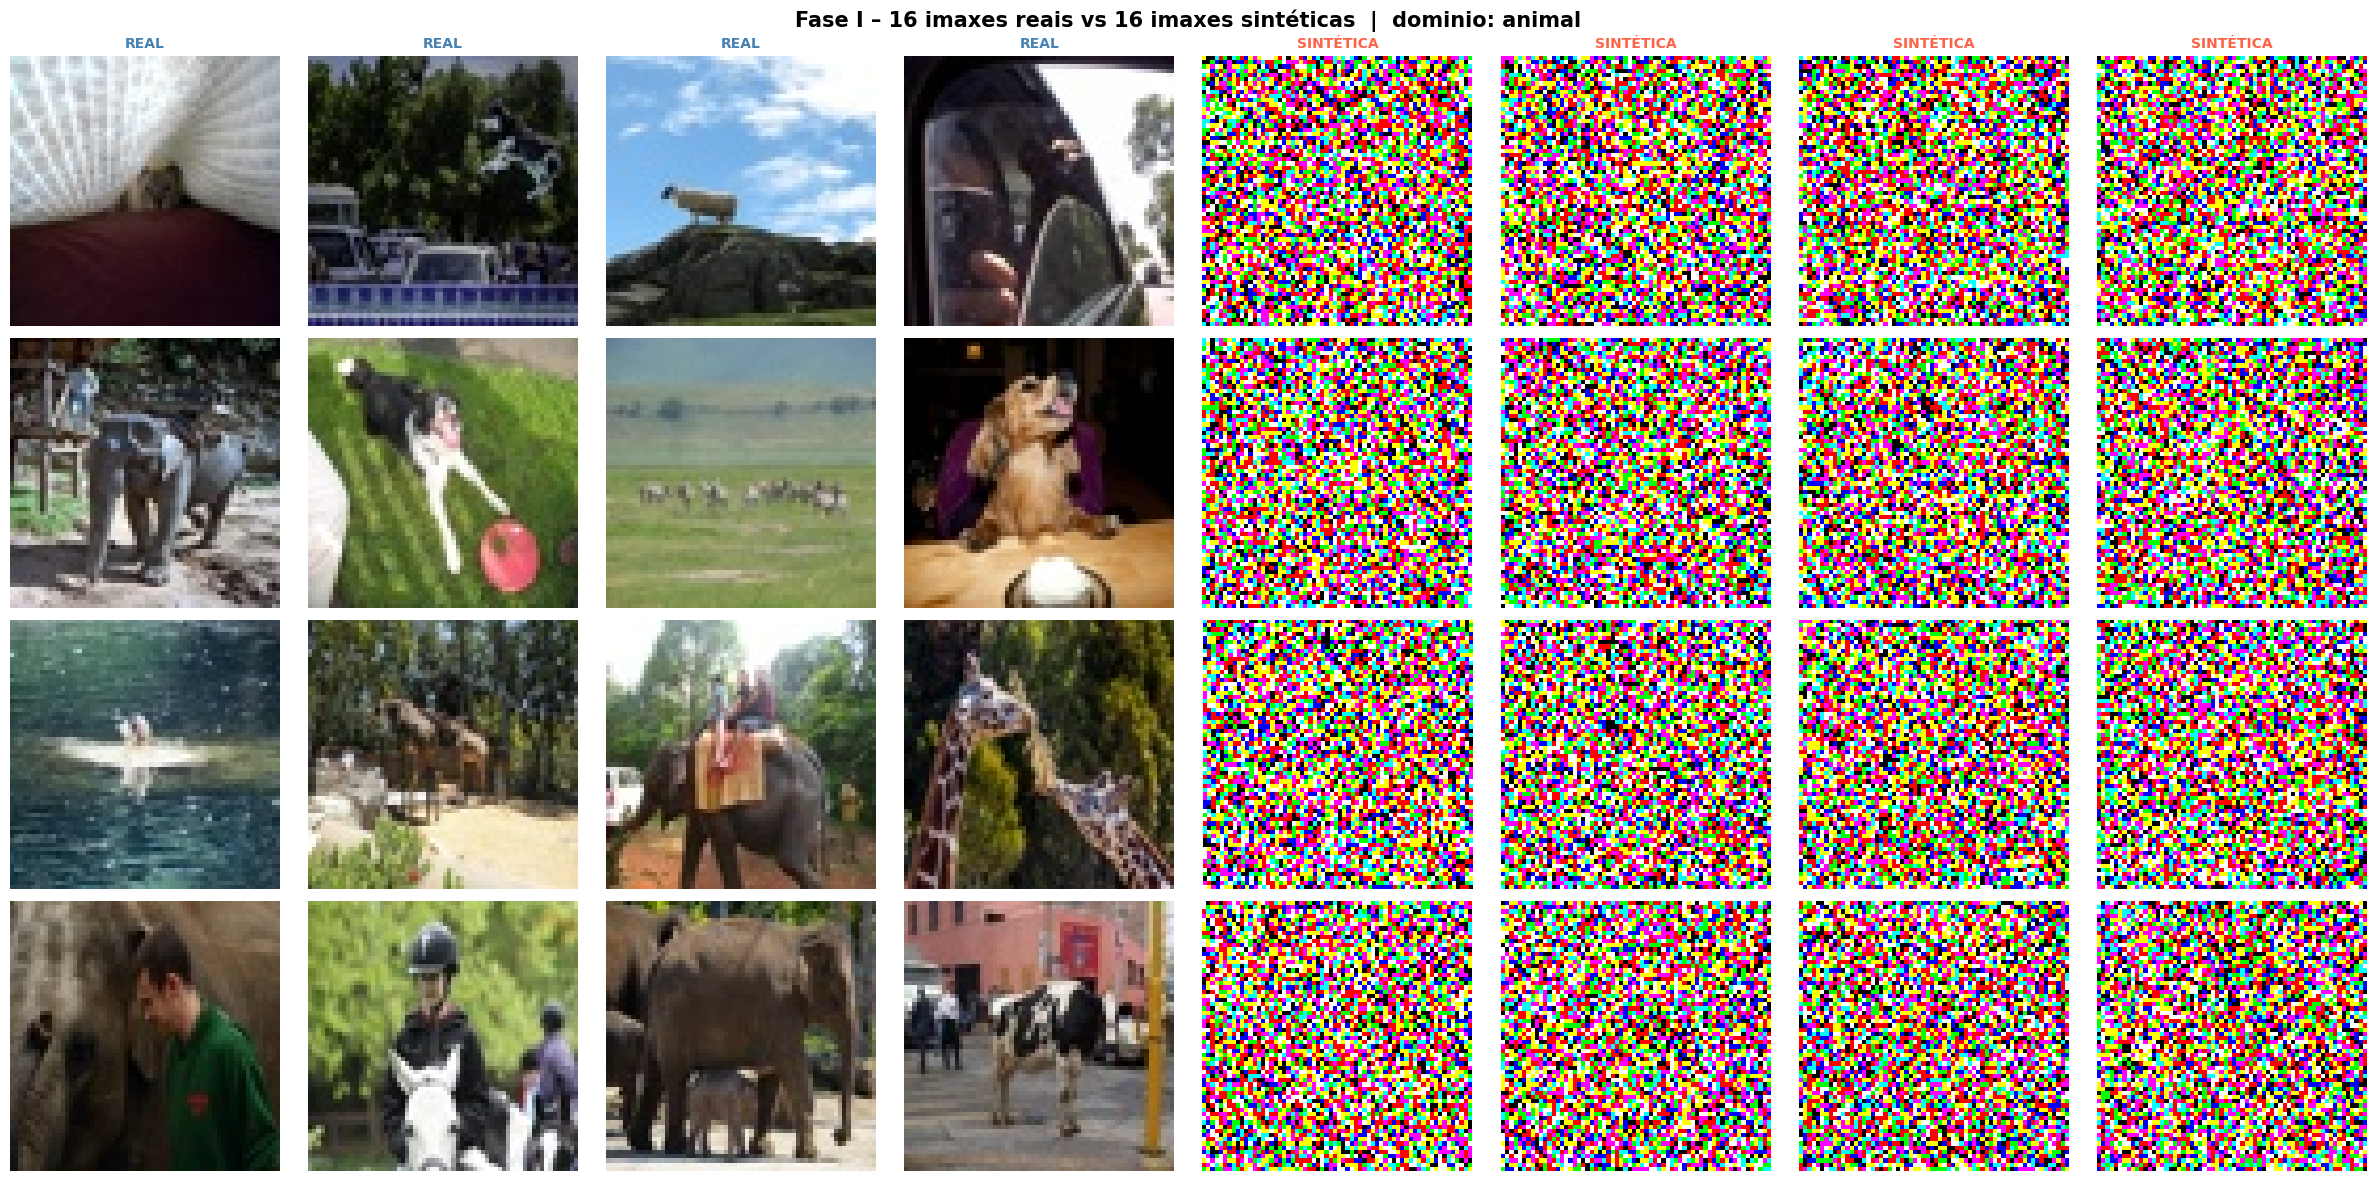

Gardado: /content/practica_2/resultados/fase1_grid_16v16_comparativo.png
Checklist fase1_grid_16v16 = True


In [ ]:
def listar_imagenes(ruta):
    if not Path(ruta).exists():
        return []
    return sorted([
        p for p in Path(ruta).iterdir()
        if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}
    ])


def make_grid_fig(paths, n=16, titulo='Grid', seed=42):
    """Crea unha figura matplotlib con n imaxes en grade 4×4."""
    random.seed(seed)
    picks = random.sample(paths, k=min(n, len(paths)))
    cols  = 4
    rows  = math.ceil(len(picks) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.array(axes).reshape(rows, cols)

    for ax in axes.flat:
        ax.axis('off')
    for ax, p in zip(axes.flat, picks):
        ax.imshow(np.array(Image.open(p).convert('RGB')))
        ax.axis('off')

    fig.suptitle(titulo, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig


# Grid comparativo nun único ficheiro
reales_paths    = listar_imagenes(RUTAS['reales_fase1'])
generadas_paths = listar_imagenes(RUTAS['generadas_fase1'])

if reales_paths and generadas_paths:
    random.seed(42)
    picks_real = random.sample(reales_paths,    k=min(16, len(reales_paths)))
    picks_gen  = random.sample(generadas_paths, k=min(16, len(generadas_paths)))

    fig, axes = plt.subplots(4, 8, figsize=(24, 12))
    for ax in axes.flat:
        ax.axis('off')

    # Columnas 0-3: reais | Columnas 4-7: sintéticas
    for col in range(4):
        axes[0, col].set_title('REAL', fontsize=10, color='steelblue', fontweight='bold')
        axes[0, col + 4].set_title('SINTÉTICA', fontsize=10, color='tomato', fontweight='bold')

    for i in range(16):
        row, col = divmod(i, 4)
        axes[row, col].imshow(np.array(Image.open(picks_real[i]).convert('RGB')))
        axes[row, col + 4].imshow(np.array(Image.open(picks_gen[i]).convert('RGB')))

    fig.suptitle(
        f'Fase I – 16 imaxes reais vs 16 imaxes sintéticas  |  dominio: {SUPERCATEGORIA}',
        fontsize=15, fontweight='bold'
    )
    plt.tight_layout()
    out_grid = OUT / 'fase1_grid_16v16_comparativo.png'
    fig.savefig(out_grid, dpi=180, bbox_inches='tight')
    plt.show()
    print('Gardado:', out_grid)
    CHECKLIST['fase1_grid_16v16'] = True
else:
    print('Faltan imaxes reais ou sintéticas para o grid comparativo.')
    CHECKLIST['fase1_grid_16v16'] = False

print('Checklist fase1_grid_16v16 =', CHECKLIST['fase1_grid_16v16'])


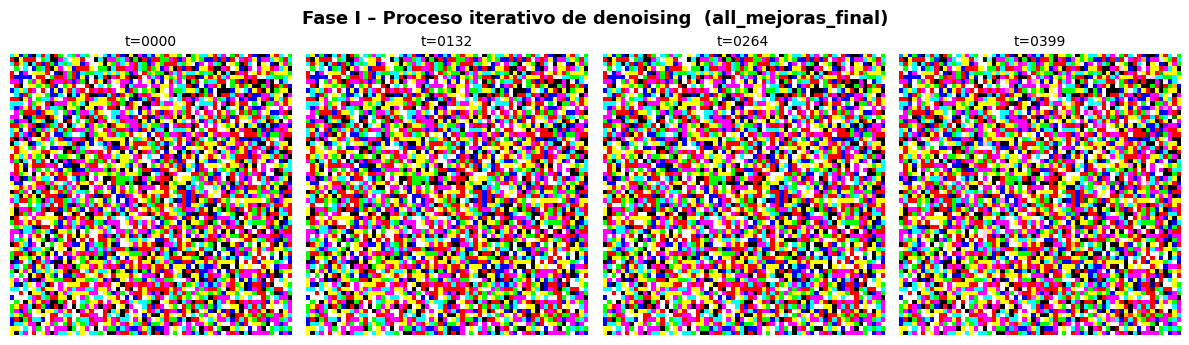

Gardado: /content/practica_2/resultados/fase1_denoising_steps.png


In [ ]:
# Proceso iterativo de denoising
denoising_paths = [
    p for p in listar_imagenes(RUTAS['denoising_fase1'])
    if 'step' in p.stem.lower()
]

if denoising_paths:
    n_steps = len(denoising_paths)
    fig, axes = plt.subplots(1, n_steps, figsize=(3 * n_steps, 3.5))
    if n_steps == 1:
        axes = [axes]

    for ax, p in zip(axes, denoising_paths):
        ax.imshow(np.array(Image.open(p).convert('RGB')))
        t_label = p.stem.replace('step_', 't=')
        ax.set_title(t_label, fontsize=10)
        ax.axis('off')

    fig.suptitle(
        f'Fase I – Proceso iterativo de denoising  ({best_name})',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    out_denoise = OUT / 'fase1_denoising_steps.png'
    fig.savefig(out_denoise, dpi=180, bbox_inches='tight')
    plt.show()
    print('Gardado:', out_denoise)
else:
    print('Non se atoparon imaxes de denoising.')


## Fase I – Paso 9: Avaliación métrica (FID)

Calculamos o **FID (Fréchet Inception Distance)** entre as características das imaxes reais e as xeradas.  
Valores máis baixos indican mellor calidade e diversidade. Un modelo aleatorio non adestrado terá FID moi alto (~300+).


In [ ]:
from scipy.linalg import sqrtm
from torchvision.models import inception_v3, Inception_V3_Weights


def cargar_imagenes_tensor(ruta, max_imgs=500):
    """Carga ata max_imgs imaxes como tensor [N, 3, H, W] en float32 [0, 1]."""
    paths = listar_imagenes(ruta)[:max_imgs]
    if not paths:
        return None
    xs = []
    for p in paths:
        arr = np.asarray(Image.open(p).convert('RGB'), dtype=np.float32) / 255.0
        xs.append(torch.from_numpy(arr).permute(2, 0, 1))
    return torch.stack(xs, dim=0)


@torch.no_grad()
def get_inception_features(images, feature_extractor, batch_size=32):
    """Extrae features da capa penúltima de InceptionV3."""
    features = []
    for i in range(0, images.shape[0], batch_size):
        batch = images[i:i + batch_size].to(DEVICE)
        # InceptionV3 espera [0,1] e resolución 299×299
        batch = F.interpolate(batch, size=(299, 299), mode='bilinear', align_corners=False)
        feats = feature_extractor(batch)
        if isinstance(feats, tuple):
            feats = feats[0]
        features.append(feats.cpu())
    return torch.cat(features, dim=0).numpy()


def calculate_fid(real_feats, fake_feats, eps=1e-6):
    """Calcula FID entre dúas distribucións de features."""
    mu_r = np.mean(real_feats, axis=0)
    mu_f = np.mean(fake_feats, axis=0)

    sigma_r = np.cov(real_feats, rowvar=False) + eps * np.eye(real_feats.shape[1])
    sigma_f = np.cov(fake_feats, rowvar=False) + eps * np.eye(fake_feats.shape[1])

    covmean = sqrtm(sigma_r @ sigma_f)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    diff = mu_r - mu_f
    fid  = float(diff @ diff + np.trace(sigma_r + sigma_f - 2 * covmean))
    return fid


# ─── Carga de datos e cálculo ────────────────────────────────────────────────
print('Cargando imaxes para FID...')
reales_t    = cargar_imagenes_tensor(RUTAS['reales_fase1'],    max_imgs=500)
generadas_t = cargar_imagenes_tensor(RUTAS['generadas_fase1'], max_imgs=500)

if reales_t is None or generadas_t is None:
    print('Faltan imaxes para calcular FID.')
    CHECKLIST['fase1_fid'] = False
else:
    print(f'Reais: {reales_t.shape} | Sintéticas: {generadas_t.shape}')

    # Cargamos InceptionV3 preadestrado e eliminamos a capa de clasificación
    inception = inception_v3(weights=Inception_V3_Weights.DEFAULT)
    inception.fc = nn.Identity()
    inception = inception.to(DEVICE)
    inception.eval()

    print('Extraendo features InceptionV3...')
    real_feats = get_inception_features(reales_t,    inception, batch_size=32)
    fake_feats = get_inception_features(generadas_t, inception, batch_size=32)

    fid_valor = calculate_fid(real_feats, fake_feats)

    # Gardar en JSON
    fid_path = RUTAS['metricas'] / 'fid_fase1.json'
    fid_results = {
        'dominio'           : SUPERCATEGORIA,
        'run_mode'          : RUN_MODE,
        'mellor_experimento': best_name,
        'n_reais'           : len(reales_t),
        'n_sinteticas'      : len(generadas_t),
        'fid'               : round(fid_valor, 4),
    }
    with open(fid_path, 'w', encoding='utf-8') as f:
        json.dump(fid_results, f, indent=2)

    CHECKLIST['fase1_fid'] = True

    print('─' * 45)
    print(f'  FID (Fréchet Inception Distance): {fid_valor:.2f}')
    print(f'  (Valores máis baixos = mellor calidade)')
    print('─' * 45)
    print('Gardado:', fid_path)

print('Checklist fase1_fid =', CHECKLIST['fase1_fid'])


Cargando imaxes para FID...
Reais: torch.Size([500, 3, 64, 64]) | Sintéticas: torch.Size([64, 3, 64, 64])
Extraendo features InceptionV3...
─────────────────────────────────────────────
  FID (Fréchet Inception Distance): 362.11
  (Valores máis baixos = mellor calidade)
─────────────────────────────────────────────
Gardado: /content/practica_2/resultados/metricas/fid_fase1.json
Checklist fase1_fid = True


## Fase I – Resumo final

Gardamos o modelo adestrado e amosamos o estado do checklist da Fase I.


In [ ]:
# Gardar o mellor modelo
model_path = OUT / f'modelo_fase1_{best_name}.pt'
torch.save({
    'model_state_dict' : best_model.state_dict(),
    'ddpm_timesteps'   : best_ddpm.timesteps,
    'ddpm_schedule'    : resultados_fase1[best_name]['cfg'].get('schedule', 'unknown'),
    'supercategoria'   : SUPERCATEGORIA,
    'run_mode'         : RUN_MODE,
    'loss_final'       : best_loss,
}, model_path)
print('Modelo gardado en:', model_path)

# ─── Checklist final Fase I ──────────────────────────────────────────────────
print('\n' + '═' * 50)
print('  CHECKLIST – FASE I')
print('═' * 50)
for key, val in CHECKLIST.items():
    estado = '✓' if val else '✗'
    print(f'  {estado}  {key}')
print('═' * 50)
print('\nComparación de experimentos:')
for nome, res in resultados_fase1.items():
    marker = ' ← MELLOR' if nome == best_name else ''
    print(f'  {nome:30s}  loss={res["loss"]:.5f}{marker}')

Modelo gardado en: /content/practica_2/resultados/modelo_fase1_all_mejoras_final.pt

══════════════════════════════════════════════════
  CHECKLIST – FASE I
══════════════════════════════════════════════════
  ✓  fase1_dominio
  ✓  fase1_grid_16v16
  ✓  fase1_denoising
  ✓  fase1_fid
══════════════════════════════════════════════════

Comparación de experimentos:
  baseline_linear                 loss=0.08659
  aug_only                        loss=0.08512
  aug_attn_cosine                 loss=0.09539
  all_mejoras_final               loss=0.09951 ← MELLOR


---
## Fase II – Difusión condicionada por texto

As celdas seguintes corresponden á **Fase II** do proxecto (Stable Diffusion + CLIP Score).  
Execútalas unha vez completada e validada a Fase I.


In [ ]:
# ─── Fase II: Extraer prompts de captions de COCO ───────────────────────────

captions_path  = Path('annotations') / 'captions_val2017.json'
instances_path = Path('annotations') / 'instances_val2017.json'


def extraer_prompts_dominio(supercategoria=SUPERCATEGORIA, max_prompts=20):
    if not captions_path.exists() or not instances_path.exists():
        print('Non se atoparon anotacións de COCO en annotations/.')
        return []

    with open(instances_path, 'r', encoding='utf-8') as f:
        inst = json.load(f)
    with open(captions_path, 'r', encoding='utf-8') as f:
        caps = json.load(f)

    cat_ids = {c['id'] for c in inst['categories'] if c['supercategory'] == supercategoria}
    img_ids = {a['image_id'] for a in inst['annotations'] if a['category_id'] in cat_ids}
    prompts = [a['caption'] for a in caps['annotations'] if a['image_id'] in img_ids]
    prompts = [p.strip() for p in prompts if p.strip()]
    random.shuffle(prompts)
    return prompts[:max_prompts]


prompts_dominio = extraer_prompts_dominio(supercategoria=SUPERCATEGORIA, max_prompts=10)
print('Prompts extraídos:', len(prompts_dominio))
for i, p in enumerate(prompts_dominio[:5], 1):
    print(f'{i}. {p}')


Prompts extraídos: 10
1. Several people standing out at a watery ledge with horses.
2. A group of giraffe Standing up against a dirt wall in front of a crowd of children.
3. An up close shot of a seagull flying in front of the beach
4. Two giraffes standing in a desert like area.
5. TWO GIRAFFES STANDING IN THE SHADE OF A TREE.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Xerada: /content/practica_2/resultados/fase2_cfg/cfg_7.5.png


  0%|          | 0/30 [00:00<?, ?it/s]

Xerada: /content/practica_2/resultados/fase2_cfg/cfg_10.0.png


  0%|          | 0/30 [00:00<?, ?it/s]

Xerada: /content/practica_2/resultados/fase2_cfg/cfg_12.0.png


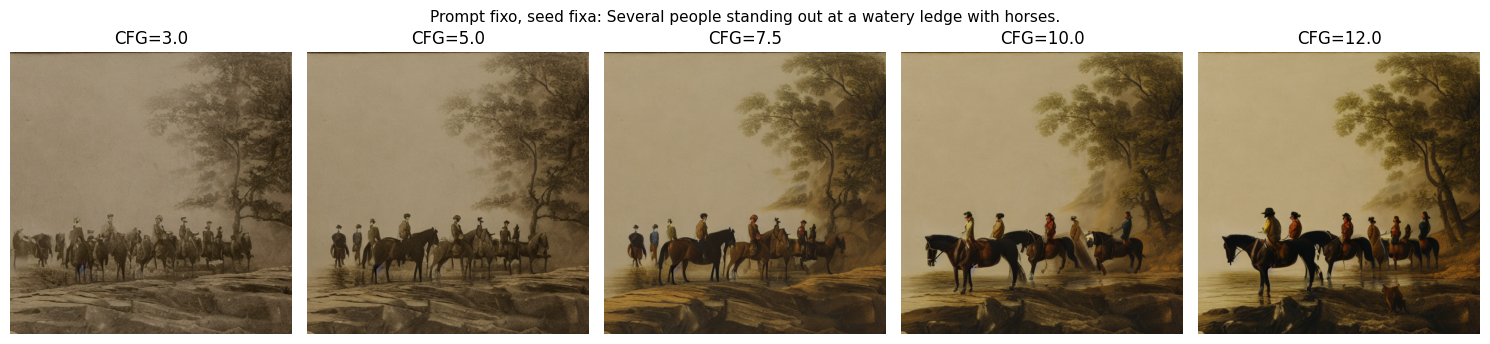

Gardado: /content/practica_2/resultados/fase2_cfg_sweep.png
Checklist fase2_cfg_grid = True


In [ ]:
# ─── Fase II: Xeración por barrido CFG (mesma seed e prompt) ─────────────────

CFG_VALUES  = [3.0, 5.0, 7.5, 10.0, 12.0]
PROMPT_BASE = prompts_dominio[0] if prompts_dominio else 'a dog running on grass'
SEED_BASE   = 42

RUTAS['cfg_fase2'] = OUT / 'fase2_cfg'
RUTAS['cfg_fase2'].mkdir(parents=True, exist_ok=True)


def generar_cfg_sweep(prompt=PROMPT_BASE, seed=SEED_BASE, cfg_values=CFG_VALUES):
    try:
        from diffusers import StableDiffusionPipeline
    except Exception as e:
        print('Non se puido importar diffusers:', e)
        return []

    device   = 'cuda' if torch.cuda.is_available() else 'cpu'
    model_id = 'runwayml/stable-diffusion-v1-5'
    pipe     = StableDiffusionPipeline.from_pretrained(model_id)
    pipe     = pipe.to(device)

    out_files = []
    for cfg in cfg_values:
        g     = torch.Generator(device=device).manual_seed(seed)
        image = pipe(prompt, guidance_scale=float(cfg),
                     num_inference_steps=30, generator=g).images[0]
        out_path = RUTAS['cfg_fase2'] / f'cfg_{cfg:.1f}.png'
        image.save(out_path)
        out_files.append((cfg, out_path))
        print('Xerada:', out_path)
    return out_files


cfg_outputs = generar_cfg_sweep()
if cfg_outputs:
    cols = len(cfg_outputs)
    fig, axes = plt.subplots(1, cols, figsize=(3 * cols, 3.5))
    if cols == 1:
        axes = [axes]
    for ax, (cfg, p) in zip(axes, cfg_outputs):
        ax.imshow(Image.open(p).convert('RGB'))
        ax.set_title(f'CFG={cfg}')
        ax.axis('off')
    fig.suptitle(f'Prompt fixo, seed fixa: {PROMPT_BASE[:80]}', fontsize=11)
    plt.tight_layout()
    out_fig = OUT / 'fase2_cfg_sweep.png'
    fig.savefig(out_fig, dpi=180, bbox_inches='tight')
    plt.show()
    print('Gardado:', out_fig)
    CHECKLIST['fase2_cfg_grid'] = True
else:
    CHECKLIST['fase2_cfg_grid'] = False
print('Checklist fase2_cfg_grid =', CHECKLIST.get('fase2_cfg_grid'))


In [ ]:
# ─── Fase II: CLIP Score ─────────────────────────────────────────────────────

def clip_score_lote(prompt, image_paths):
    try:
        from transformers import CLIPProcessor, CLIPModel
    except Exception as e:
        print('Non se puido importar transformers:', e)
        return None

    device    = 'cuda' if torch.cuda.is_available() else 'cpu'
    model_id  = 'openai/clip-vit-base-patch32'
    clip_model = CLIPModel.from_pretrained(model_id).to(device)
    processor  = CLIPProcessor.from_pretrained(model_id)

    scores = []
    for p in image_paths:
        img    = Image.open(p).convert('RGB')
        inputs = processor(text=[prompt], images=img, return_tensors='pt', padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            out = clip_model(**inputs)
            txt = out.text_embeds  / out.text_embeds.norm(dim=-1, keepdim=True)
            im  = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
            scores.append(float((txt * im).sum(dim=-1).item()))

    return {
        'scores': scores,
        'media' : float(np.mean(scores)) if scores else None,
        'std'   : float(np.std(scores))  if scores else None,
    }


cfg_imgs    = listar_imagenes(RUTAS['cfg_fase2'])
clip_stats  = clip_score_lote(PROMPT_BASE, cfg_imgs) if cfg_imgs else None

if clip_stats:
    clip_path = RUTAS['metricas'] / 'clip_score.json'
    with open(clip_path, 'w', encoding='utf-8') as f:
        json.dump({'prompt': PROMPT_BASE, 'seed': SEED_BASE,
                   'n_imagenes': len(cfg_imgs), 'clip_score': clip_stats}, f, indent=2)
    CHECKLIST['fase2_clip_score'] = True
    print('CLIP media:', clip_stats['media'])
    print('CLIP std  :', clip_stats['std'])
    print('Gardado:', clip_path)
else:
    CHECKLIST['fase2_clip_score'] = False
print('Checklist fase2_clip_score =', CHECKLIST.get('fase2_clip_score'))


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP media: 0.3271651864051819
CLIP std  : 0.007047980619230146
Gardado: /content/practica_2/resultados/metricas/clip_score.json
Checklist fase2_clip_score = True
